In [3]:
import tensorflow as tf
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =====================================================
# NOTEBOOK-SAFE PATH SETUP  ✅
# =====================================================
# In notebooks, __file__ does NOT exist
PROJECT_ROOT = Path(os.getcwd()).resolve().parent
sys.path.append(str(PROJECT_ROOT))

from data_pipeline import train_ds, test_ds

# =====================================================
# LOAD AUTOENCODER MODEL  ✅
# =====================================================
MODEL_DIR = PROJECT_ROOT / "model"
model_path = MODEL_DIR / "con_aen_model.keras"
encoder_model_path = MODEL_DIR / "con_aen_encoder_model.keras"

if not model_path.exists():
    raise FileNotFoundError(f"Model file not found at: {model_path}")

print(f"Loading autoencoder model from {encoder_model_path}")
autoencoder_model = tf.keras.models.load_model(model_path)

# =====================================================
# SAFE DATA EXTRACTION (NO ZEROING, NO SHUFFLE LOSS) ✅
# =====================================================
def get_data_and_labels(dataset):
    images, labels = [], []
    for batch_imgs, batch_labels in dataset:
        images.append(batch_imgs.numpy())
        labels.append(batch_labels.numpy())

    X = np.concatenate(images, axis=0)
    y = np.concatenate(labels, axis=0).reshape(-1)

    return X, y

print("Extracting data and labels...")
X_train, y_train = get_data_and_labels(train_ds)
X_test, y_test   = get_data_and_labels(test_ds)

print(f"Train samples: {X_train.shape}, Test samples: {X_test.shape}")

# =====================================================
# SANITY CHECK (CRITICAL) 🔍
# =====================================================
print("X_train min:", X_train.min(), "max:", X_train.max())
print("X_test  min:", X_test.min(),  "max:", X_test.max())

# =====================================================
# GENERATE RECONSTRUCTIONS  ✅
# =====================================================
print("Generating reconstructed images...")
X_train_recon = autoencoder_model.predict(X_train, batch_size=32)
X_test_recon  = autoencoder_model.predict(X_test, batch_size=32)
print("Reconstruction complete.")

# Ensure proper visualization range
X_train_recon = np.clip(X_train_recon, 0.0, 1.0)
X_test_recon  = np.clip(X_test_recon, 0.0, 1.0)

# Extracting latent features
encoder_model = tf.keras.models.load_model(encoder_model_path)

X_train_feat = encoder_model.predict(X_train,  batch_size=32)
X_test_feat  = encoder_model.predict(X_test,  batch_size=32)
X_train_feat = np.clip(X_train_feat, 0.0, 1.0)
X_test_feat  = np.clip(X_test_feat, 0.0, 1.0)

# =====================================================
# VISUALIZATION FUNCTION  ✅
# =====================================================
def plot_reconstructions(original, reconstructed, n=5):
    plt.figure(figsize=(3*n, 6))

    for i in range(n):
        # Original
        plt.subplot(2, n, i + 1)
        plt.imshow(original[i])
        plt.title("Original")
        plt.axis("off")

        # Reconstructed
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i])
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

print("Plotting sample reconstructions from test set...")
plot_reconstructions(X_test, X_test_recon, n=5)



mean_fresh  = X_train_recon[y_train == 0].mean(axis=0)
mean_rotten = X_train_recon[y_train == 1].mean(axis=0)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Mean Fresh Recon")
plt.imshow(mean_fresh)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mean Rotten Recon")
plt.imshow(mean_rotten)
plt.axis("off")
plt.show()


Loading autoencoder model from /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/model/con_aen_encoder_model.keras
Extracting data and labels...


2026-01-18 13:04:03.368602: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-18 13:04:03.373364: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-18 13:04:03.381804: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-18 13:04:03.384058: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-18 13:04:03.394605: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-18 13:04:03.435600: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-18 13:04:03.440894: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-18 13:04:03.454826: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2026-01-18 13:04:03.478804: W tensorflow/core/lib/png/png_io.cc:95] PNG 

KeyboardInterrupt: 

2026-01-18 21:20:17.404543: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-18 21:20:17.410801: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-18 21:20:17.713016: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-18 21:20:26.277925: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Loading Train Dataset...
Found 2420 files belonging to 10 classes.


2026-01-18 21:20:32.960474: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Mapping 10 folders to 2 classes:
  Folder 'freshapples' -> Healthy
  Folder 'freshbittergroud' -> Healthy
  Folder 'freshoranges' -> Healthy
  Folder 'freshpotato' -> Healthy
  Folder 'freshtomato' -> Healthy
  Folder 'rottenapples' -> Rotten
  Folder 'rottenbittergroud' -> Rotten
  Folder 'rottenoranges' -> Rotten
  Folder 'rottenpotato' -> Rotten
  Folder 'rottentomato' -> Rotten

Loading Test Dataset...
Found 1745 files belonging to 8 classes.
Mapping 8 folders to 2 classes:
  Folder 'freshapples' -> Healthy
  Folder 'freshoranges' -> Healthy
  Folder 'freshpatato' -> Healthy
  Folder 'freshtamto' -> Healthy
  Folder 'rottenapples' -> Rotten
  Folder 'rottenoranges' -> Rotten
  Folder 'rottenpatato' -> Rotten
  Folder 'rottentamto' -> Rotten
Loading CNN classifier model...

Loading Banana Dataset for Prediction...
Found 600 files belonging to 2 classes.


2026-01-18 21:20:45.687345: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Extracted 600 banana samples.

Sample Predictions on Banana Data:
0.93425274
Sample 482: True=Rotten, Pred=Rotten (93.43% confidence)
0.399768
Sample 487: True=Healthy, Pred=Healthy (60.02% confidence)
0.3626033
Sample 460: True=Healthy, Pred=Healthy (63.74% confidence)
0.6668017
Sample 4: True=Healthy, Pred=Healthy (33.32% confidence)
0.30260244
Sample 327: True=Rotten, Pred=Healthy (69.74% confidence)


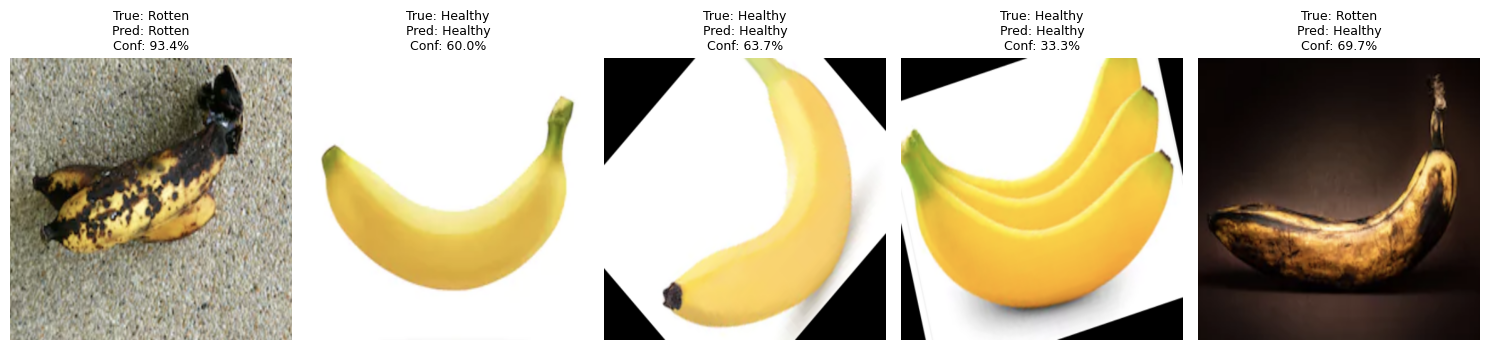

In [1]:
import tensorflow as tf
from os import path as os_path
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- PATH SETUP ----------
# Project root
PROJECT_ROOT = Path(os.getcwd()).resolve().parent
sys.path.append(str(PROJECT_ROOT))  # Add project root to import data_pipeline

from data_pipeline import load_dataset, normalize

# Model paths
MODEL_DIR = PROJECT_ROOT / "model"
# Autoencoder path (commented, kept as placeholder)
aen_model_path = MODEL_DIR / "con_aen_model.keras"
# CNN classifier path
cnn_model_path = MODEL_DIR / "cnn_classifier_model.keras"

# Dataset path
DATASET_PATH = PROJECT_ROOT / "data/prediction_use_dataset"

# ---------- LOAD CNN CLASSIFIER ----------
print("Loading CNN classifier model...")
cnn_classifier_model = tf.keras.models.load_model(cnn_model_path)

# ---------- LOAD BANANA TEST DATA ----------
print("\nLoading Banana Dataset for Prediction...")
banana_test_ds = load_dataset(DATASET_PATH / "Test", "banana")
banana_test_ds = banana_test_ds.map(normalize)

# ---------- EXTRACT IMAGES AND LABELS ----------
def get_data_and_labels(dataset):
    images = []
    labels = []
    for img, label in dataset.as_numpy_iterator():
        images.append(img)
        labels.append(label)
    return np.concatenate(images, axis=0), np.concatenate(labels, axis=0)

X_banana, y_banana = get_data_and_labels(banana_test_ds)
print(f"Extracted {len(X_banana)} banana samples.")

# ---------- SAMPLE PREDICTIONS & VISUALIZATION ----------
print("\nSample Predictions on Banana Data:")

num_samples = 5
indices = np.random.choice(len(X_banana), num_samples, replace=False)

plt.figure(figsize=(15, 4))
for idx, i in enumerate(indices):
    img = X_banana[i:i+1]
    true_label = "Rotten" if y_banana[i] == 1 else "Healthy"
    
    # Prediction
    prediction = cnn_classifier_model.predict(img, verbose=0)[0][0]
    print(prediction)
    pred_label = "Rotten" if prediction > 0.75 else "Healthy"
    confidence = prediction if prediction > 0.75 else 1 - prediction
    
    print(f"Sample {i}: True={true_label}, Pred={pred_label} ({confidence*100:.2f}% confidence)")
    
    # Plot image
    plt.subplot(1, num_samples, idx+1)
    plt.imshow(np.squeeze(img))  # Remove batch dimension
    plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence*100:.1f}%", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# ---------- OVERALL EVALUATION ----------
# print("\nOverall Evaluation on Banana Test Set:")
# loss, acc = cnn_classifier_model.evaluate(X_banana, y_banana, verbose=1)


In [3]:
import os
import sys
import tensorflow as tf
from tensorflow.keras import layers, models

# ---------- SYSTEM SAFETY ----------
# Allow duplicate OpenMP libraries to prevent conflicts
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

# Enable GPU memory growth to avoid allocating all memory at once
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# ---------- DATA IMPORT ----------
# Import pre-processed data from aen_reconstruction script
# This assumes that aen_reconstruction.py performs the necessary data loading and preprocessing
try:
    from aen_reconstruction import X_train, X_test, y_train, y_test
    print("Data loaded successfully")
    print("Train shape:", X_train.shape)
except ImportError as e:
    print("Data import failed:", e)
    sys.exit(1)

# ---------- LOAD ENCODER ----------
MODEL_DIR = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "model"))
ENCODER_PATH = os.path.join(MODEL_DIR, "con_aen_encoder_model.keras")

if not os.path.exists(ENCODER_PATH):
    print(f"Error: Encoder model not found at {ENCODER_PATH}")
    print("Please train the autoencoder first using 'src/convolutional_autoencoder/con_aen.py'")
    sys.exit(1)

print(f"Loading encoder from: {ENCODER_PATH}")
encoder = tf.keras.models.load_model(ENCODER_PATH)
encoder.trainable = False  # Freeze encoder to use it as a feature extractor

# ---------- MODEL DEFINITION ----------
# Define the input shape based on the training data
INPUT_SHAPE = X_train.shape[1:]  # safer than hardcoding

inputs = layers.Input(shape=INPUT_SHAPE)

# Encoder: Extract features from the input image
x = encoder(inputs)

# Ensure proper shape for the dense layers
# If the encoder output is 4D (batch, height, width, channels), pool it to 2D
if len(x.shape) == 4:
    x = layers.GlobalAveragePooling2D()(x)

# Classification Head: Fully connected layers for binary classification
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# Output layer: Sigmoid activation for binary classification (0 or 1)
outputs = layers.Dense(1, activation="sigmoid")(x)

cnn = models.Model(inputs, outputs)

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

cnn.summary()

# ---------- TRAINING ----------
# Early stopping to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("Starting training...")
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32,
    callbacks=[early_stop]
)

# ---------- SAVE MODEL ----------
os.makedirs(MODEL_DIR, exist_ok=True)
SAVE_PATH = os.path.join(MODEL_DIR, "cnn_classifier_model.keras")
cnn.save(SAVE_PATH)
print(f"Model saved successfully at {SAVE_PATH}")

# ---------- EVALUATION ----------
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Create results directory
RESULTS_DIR = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", "results"))
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Evaluating model...")

# Predict on test set
y_pred_prob = cnn.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification Report
report = classification_report(y_test, y_pred, target_names=["Healthy", "Rotten"])
print("Classification Report:")
print(report)

# Save Classification Report to file
with open(os.path.join(RESULTS_DIR, "cnn_classification_report.txt"), "w") as f:
    f.write("Confusion Matrix:\n")
    f.write(str(cm))
    f.write("\n\nClassification Report:\n")
    f.write(report)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Rotten"])
disp.plot(cmap=plt.cm.Blues)
plt.title("CNN Confusion Matrix")
plt.savefig(os.path.join(RESULTS_DIR, "cnn_confusion_matrix.png"))
plt.close()

# Plot Training History
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cnn_training_history.png"))
plt.close()

print(f"Evaluation results saved to {RESULTS_DIR}")


Extracting data and labels from datasets...


2026-01-18 21:40:10.987432: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/data/train_test_dataset/Train/freshtomato/DSCN4102.jpg_0_490.jpg; No such file or directory
2026-01-18 21:40:10.987465: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/data/train_test_dataset/Train/freshtomato/DSCN4070.jpg_0_342.jpg; No such file or directory
2026-01-18 21:40:10.987542: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/data/train_test_dataset/Train/rottenoranges/Screen Shot 2018-06-12 at 11.24.43 PM.png; No such file or directory
2026-01-18 21:40:10.987549: W tensorflow/core/framework/op

NotFoundError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/data/train_test_dataset/Train/freshoranges/Screen Shot 2018-06-13 at 12.03.34 AM.png; No such file or directory
	 [[{{node ReadFile}}]] [Op:IteratorGetNext] name: 

/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/data/train_test_dataset/Train/freshbittergroud/IMG_20200822_223840.jpg_0_9990.jpg; No such file or directory
2026-01-18 21:40:11.070580: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/data/train_test_dataset/Train/rottenbittergroud/IMG_20200825_144547.jpg_0_4807.jpg; No such file or directory
2026-01-18 21:40:11.070592: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/data/train_test_dataset/Train/rottentomato/Copy of IMG_20200729_164219.jpg_0_6060.jpg; No such file or directory
2026-01-18 21:40:11.070603: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: /home/aishwarya/Documents/colz/Msc-DSC